# Primary example

## Model: 30-bus

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import gurobipy as gp
from gurobipy import GRB
import random

# Data initialization

In [2]:
# initialize relevant data
current_filepath = Path('.').resolve().parent
data_path = current_filepath / 'raw-data' / 'larger-model-processed' / '30-bus'

branches_df = pd.read_csv(filepath_or_buffer=data_path / 'branches.csv', skiprows=1)
buses_df = pd.read_csv(filepath_or_buffer=data_path / 'buses.csv', skiprows=1)
ptdf_df = pd.read_csv(filepath_or_buffer=data_path / 'ptdf.csv', skiprows=1)
sf_contingencies_df = pd.read_csv(filepath_or_buffer=data_path / 'sf-contingencies.csv', skiprows=1)

# Limit Generation

In [3]:
random.seed(370)
np.random.seed(370)

branches_df.loc[branches_df["Lim MVA A"] == 0, "Lim MVA A"] = [random.choice([260, 520]) for _ in range(branches_df.loc[branches_df["Lim MVA A"] == 0].shape[0])]

# Bid stack generation

In [4]:
gens = pd.read_csv(filepath_or_buffer=data_path / 'gens.csv', skiprows=1)
gens.head()

,Number of Bus,Name of Bus,ID,Status,Gen MW,Gen Mvar,Min MW,Max MW,AGC,AVR,RegBus Num,Set Volt,Min Mvar,Max Mvar,Enforce MW Limits,Part. Factor,Cost Model
0,1,Glen Lyn,1,Closed,260.95,-16.79,-10000.0,10000.0,YES,YES,1,1.060,0.0,0.0,YES,10000.0,NaN
1,2,Claytor,1,Closed,40.00,50.00,-10000.0,10000.0,YES,YES,2,1.045,-40.0,50.0,YES,10000.0,NaN
2,5,Fieldale,1,Closed,0.00,36.85,-10000.0,10000.0,YES,YES,5,1.010,-40.0,40.0,YES,10000.0,NaN
3,8,Reusens,1,Closed,0.00,37.14,-10000.0,10000.0,YES,YES,8,1.010,-10.0,40.0,YES,10000.0,NaN
4,11,Roanoke,1,Closed,0.00,16.17,-10000.0,10000.0,YES,YES,11,1.082,-6.0,24.0,YES,10000.0,NaN


## Generator Offers

In [5]:
generator_node = gens["Number of Bus"].to_numpy()
generator_min = np.zeros(generator_node.shape[0])
generator_max = np.zeros(generator_node.shape[0])
generator_cost = []

for i in range(generator_node.shape[0]):
    if random.randint(0, 1) == 0:
        generator_min[i] = random.randrange(10, 50, 10)
        generator_max[i] = max(generator_min[i] + 10, int(np.random.normal(125, 25)) * 10)
        
        # Assume non-zero min gen is only for thermal generators
        # Who have agreements to guaruntee production for reliability
        generator_cost.append(random.randrange(10, 15))
    else:
        generator_min[i] = 0
        generator_max[i] = max(generator_min[i] + 10, int(np.random.normal(125, 25)) * 10)
        # Assume renewables dont have min gen since they don't have such agreements
        # However they can effectively "guarantee" production by bidding negative prices
        # since they will always produce, and recieve subsidies for production
        # even if they clear at negative prices, they still make money from the
        # subsidies paying off (and to avoid shutdown costs)
        generator_cost.append(random.randrange(-10, 10))
generator_cost = np.array(generator_cost)

## Load Bids

In [6]:
load_buses = buses_df["Number"].to_numpy()
bus_to_idx = {bus: idx for idx, bus in enumerate(load_buses)}
nominal_demand = buses_df['Load MW'].replace([np.nan], 0).to_numpy()
load_node = buses_df['Number'].to_numpy()
load_node = load_node[nominal_demand != 0]
nominal_demand = nominal_demand[nominal_demand != 0]

In [7]:
load_node = buses_df['Number'].to_numpy()
nodal_bids = []
for bus in load_node:
    if bus in generator_node:
        continue # Typically loads dont place bids at buses with generators

    num_bids = random.randint(4, 15)
    for i in range(random.randint(10, max(20, int(np.sqrt(load_buses.shape[0]) * 2)))):
        nodal_bids.append({
            "bus": bus,
            "price": random.randrange(2, 25),
            "amount": np.ceil(abs(np.random.normal(0, 5)))
        })

bids = pd.DataFrame(nodal_bids).sort_values(by=["bus", "price", "amount"], ignore_index=True, ascending=[True, False, False])
bids.head()

,bus,price,amount
0,3,24,5.0
1,3,19,5.0
2,3,19,4.0
3,3,19,3.0
4,3,18,7.0


<Axes: title={'center': 'Bids for power on bus 3'}, xlabel='Price ($/MWh)', ylabel='Amount (MW)'>

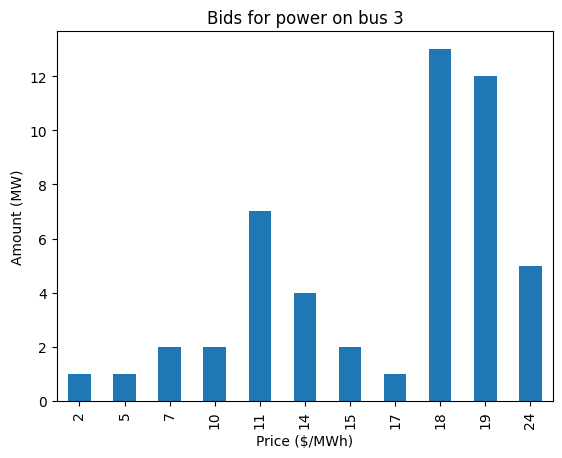

In [8]:
bid_bus = [node for node in load_node if node not in generator_node][0]
bus_bids = bids[bids["bus"] == bid_bus]
bus_bids[[
    "price", "amount"
    ]].groupby("price").sum().reset_index().plot.bar(
        x="price",
        y="amount",
        title=f"Bids for power on bus {bid_bus}",
        xlabel="Price ($/MWh)",
        ylabel="Amount (MW)",
        legend=False
        )

# Transmission Constraints

In [9]:
G = generator_cost.shape[0]
D = bids.shape[0]
bid_bus = bids["bus"].to_numpy()
bid_amount = bids["amount"].to_numpy()
bid_price = bids["price"].to_numpy()

thermal_flow_lim = branches_df['Lim MVA A'].to_numpy()

power_balance_cons_vec = np.concatenate((np.ones((G, 1)), -1*np.ones((D, 1)))).T

## Injection Mapping

In [10]:
gen_node_indices = [bus_to_idx[bus] for bus in generator_node]
bid_bus_indices = [bus_to_idx[bus] for bus in bid_bus]

In [11]:
gen_node_map = np.zeros((buses_df.shape[0], G))
gen_node_map[gen_node_indices, np.arange(G)] = 1
load_node_map = np.zeros((buses_df.shape[0], D))
load_node_map[bid_bus_indices, np.arange(D)] = -1

injection_map = np.hstack((gen_node_map, load_node_map))

## Shift Factor to Thermal Flow Mapping

In [12]:
# Create a mapping from line to thermal flow lim
thermal_flow_mapping = branches_df[['From Number', 'To Number', 'Lim MVA A']]
sf_no_contingency = ptdf_df.iloc[:, 5:]

# match the thermal flow lim to the shift factor values
sf_names = sf_no_contingency.columns.values
thermal_flow_lim = np.zeros((sf_names.shape[0]))
for (ind, line) in enumerate(sf_names):
    line_string = line.split(' ')
    from_no = int(line_string[0])
    to_no = int(line_string[4])
    thermal_flow_lim[ind] = thermal_flow_mapping.query('`From Number` == @from_no and `To Number` == @to_no')['Lim MVA A'].iloc[0]

sf_no_contingency = sf_no_contingency.to_numpy().T

In [13]:
sf_contingency = sf_contingencies_df.iloc[:, 5:]

# match the thermal flow lim to the shift factor contingency values
contingency_names = sf_contingency.columns.values
thermal_flow_lim_contingencies = np.zeros((contingency_names.shape[0]))
for (ind, contingency) in enumerate(contingency_names):
    line_string = contingency.split('_')[2]
    from_no = int(line_string.split('-')[0])
    to_no = int(line_string.split('-')[1])
    thermal_flow_lim_contingencies[ind] = thermal_flow_mapping.query('`From Number` == @from_no and `To Number` == @to_no')['Lim MVA A'].iloc[0]

sf_contingency = sf_contingency.to_numpy().T

In [14]:
base_case_trans_cons_mat = sf_no_contingency @ injection_map
contingency_trans_cons_mat = sf_contingency @ injection_map

## Model Set-up

In [15]:
lp_model = gp.Model()
generators = lp_model.addMVar(G, name='generators')
loads = lp_model.addMVar(D, name='bid_clearance', lb=0.0, ub=bid_amount)

# We maximize served demand - cost of generation
x_dispatch = gp.hstack((generators, loads))
obj_c = np.hstack((-generator_cost, bid_price))
lp_model.setMObjective(Q=None, c=obj_c, xc=x_dispatch, constant=0, sense=GRB.MAXIMIZE)

power_balance_cons = lp_model.addMConstr(power_balance_cons_vec, x_dispatch, '=', [0], 'power balance')
generator_min_cons = lp_model.addMConstr(np.eye(G), generators, '>=', generator_min, 'min generator capacity')
generator_max_cons = lp_model.addMConstr(np.eye(G), generators, '<=', generator_max, 'max generator capacity')
load_limits_cons = lp_model.addMConstr(np.eye(D), loads, '<=', bid_amount, 'max load bid')
base_case_cons_min = lp_model.addMConstr(base_case_trans_cons_mat, x_dispatch, '>=', -1 * thermal_flow_lim, 'Base Case Transmission Min')
base_case_cons_max = lp_model.addMConstr(base_case_trans_cons_mat, x_dispatch, '<=', thermal_flow_lim, 'Base Case Transmission Max')
contingency_cons_min = lp_model.addMConstr(contingency_trans_cons_mat, x_dispatch, '>=', -1 * thermal_flow_lim_contingencies, 'Contingency Transmission Min')
contingency_cons_max = lp_model.addMConstr(contingency_trans_cons_mat, x_dispatch, '<=', thermal_flow_lim_contingencies, 'Contingency Transmission Max')

lp_model.update()
lp_model.optimize()

Set parameter Username
Set parameter LicenseID to value 2762801
Academic license - for non-commercial use only - expires 2027-01-10
Set parameter LicenseID to value 2762801
Academic license - for non-commercial use only - expires 2027-01-10
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M1 Max
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 3720 rows, 351 columns and 972536 nonzeros (Max)
Model fingerprint: 0xc9910f14
Model has 351 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-04, 1e+00]
  Objective range  [2e+00, 2e+01]
  Bounds range     [1e+00, 2e+01]
  RHS range        [1e+00, 1e+03]

Presolve removed 2914 rows and 138 columns
Presolve time: 0.09s
Presolved: 806 rows, 528 columns, 166741 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier performed 0 iterations

## Solutions

In [16]:
load_results = bids.copy().sort_values(by=["bus", "price", "amount"], ignore_index=True, ascending=[True, False, False])
load_results["cleared"] = loads.X
load_results

,bus,price,amount,cleared
0,3,24,5.0,5.0
1,3,19,5.0,5.0
2,3,19,4.0,4.0
3,3,19,3.0,3.0
4,3,18,7.0,7.0
...,...,...,...,...
340,30,6,7.0,0.0
341,30,5,2.0,0.0
342,30,4,4.0,0.0
343,30,2,5.0,0.0


In [17]:
# cleared at each bus
load_results.groupby("bus")["cleared"].sum().reset_index()

,bus,cleared
0,3,37.000000
1,4,32.149898
2,6,16.000000
3,7,17.000000
4,9,21.000000
5,10,0.000000
6,12,51.437026
7,14,15.585771
8,15,7.000000
9,16,7.750707


In [18]:
# gen results
gen_results = pd.DataFrame(
    {
        "generator": np.arange(1, G + 1),
        "bus": generator_node,
        "cleared": generators.X,
        "cost": generator_cost,
        "Pmin": generator_min,
        "Pmax": generator_max
    }   
)
gen_results.head()

,generator,bus,cleared,cost,Pmin,Pmax
0,1,1,86.383223,12,10.0,890.0
1,2,2,30.000000,14,30.0,1010.0
2,3,5,70.000000,-5,0.0,1150.0
3,4,8,32.000000,10,20.0,1450.0
4,5,11,65.000000,5,0.0,1090.0


In [19]:
load_results.groupby("bus")["cleared"].sum().reset_index(drop=True)

0     37.000000
1     32.149898
2     16.000000
3     17.000000
4     21.000000
5      0.000000
6     51.437026
7     15.585771
8      7.000000
9      7.750707
10     6.000000
11     3.000000
12     5.000000
13     3.000000
14    13.621969
15     4.000000
16     7.000000
17     6.000000
18     0.000000
19    25.000000
20     7.000000
21    29.737132
22    13.000000
23    21.100720
Name: cleared, dtype: float64

In [20]:
lambda_energy = power_balance_cons.Pi[0]
mu_base_max = base_case_cons_max.Pi
mu_base_min = base_case_cons_min.Pi
mu_cont_max = contingency_cons_max.Pi
mu_cont_min = contingency_cons_min.Pi
ptdf_bus = ptdf_df.iloc[:, 5:].to_numpy()   # rows = buses, cols = lines
lmp_base = lambda_energy + ptdf_bus @ (mu_base_max + mu_base_min)
sf_bus_cont = sf_contingencies_df.iloc[:, 5:].to_numpy()   # rows = buses, cols = monitored-line/contingency pairs
lmp_sc = (lmp_base + sf_bus_cont @ (mu_cont_max + mu_cont_min)) * -1

lmp_df = pd.DataFrame({
    "bus": buses_df["Number"],
    "LMP": lmp_sc,
}).merge(
    load_results.groupby("bus")["cleared"].sum().reset_index().rename(columns={"cleared": "Load Cleared"}), on="bus", how="left"
    ).merge(
        gen_results, on="bus", how="left"
        ).drop(
            columns=["generator"]
            ).rename(
                columns={"cleared": "Gen Cleared", 
                         "cost": "Gen Cost", 
                         "Pmin": "Gen Pmin", 
                         "Pmax": "Gen Pmax"}
                )
lmp_df

,bus,LMP,Load Cleared,Gen Cleared,Gen Cost,Gen Pmin,Gen Pmax
0,1,12.000000,NaN,86.383223,12.0,10.0,890.0
1,2,12.048612,NaN,30.000000,14.0,30.0,1010.0
2,3,12.031720,37.000000,NaN,NaN,NaN,NaN
3,4,12.000000,32.149898,NaN,NaN,NaN,NaN
4,5,-5.000000,NaN,70.000000,-5.0,0.0,1150.0
5,6,12.439578,16.000000,NaN,NaN,NaN,NaN
6,7,12.358033,17.000000,NaN,NaN,NaN,NaN
7,8,10.000000,NaN,32.000000,10.0,20.0,1450.0
8,9,14.620884,21.000000,NaN,NaN,NaN,NaN
9,10,20.999649,0.000000,NaN,NaN,NaN,NaN


In [21]:
dispatch_vector = x_dispatch.X

base_case_flow = base_case_trans_cons_mat @ dispatch_vector

base_case_flow_df = pd.DataFrame({
    "branch": sf_names,
    "flow_mw": base_case_flow,
    "limit_mva": thermal_flow_lim,
})

base_case_flow_df["abs_flow_mw"] = base_case_flow_df["flow_mw"].abs()
base_case_flow_df["pct_of_limit"] = 100 * base_case_flow_df["abs_flow_mw"] / base_case_flow_df["limit_mva"]

base_case_flow_df.sort_values("abs_flow_mw", ascending=False).reset_index(drop=True)


,branch,flow_mw,limit_mva,abs_flow_mw,pct_of_limit
0,12 TO 13 CKT 1,-65.000000,65.0,65.000000,100.000000
1,9 TO 11 CKT 1,-65.000000,65.0,65.000000,100.000000
2,5 TO 7 CKT 1,55.839209,70.0,55.839209,79.770298
3,6 TO 28 CKT 1,53.997338,260.0,53.997338,20.768207
4,1 TO 3 CKT 1,51.316431,130.0,51.316431,39.474177
5,9 TO 10 CKT 1,49.457144,520.0,49.457144,9.510989
6,28 TO 27 CKT 1,43.179085,520.0,43.179085,8.303670
7,2 TO 4 CKT 1,40.328890,65.0,40.328890,62.044446
8,2 TO 6 CKT 1,38.894345,65.0,38.894345,59.837454
9,6 TO 7 CKT 1,-38.839209,130.0,38.839209,29.876314


In [22]:
spec = ['30', 'bus']
output_dir = Path('./results') / '-'.join(spec)
spec = ''.join(spec) # nice

lmp_df.to_csv(output_dir / f"lmp_results-{spec}.csv", index=False)
base_case_flow_df.sort_values("abs_flow_mw", ascending=False).reset_index(drop=True).to_csv(
    output_dir / f"base_case_flow_results-{spec}.csv", index=False
)
load_results.to_csv(output_dir / f"load_results-{spec}.csv", index=False)
branches_df.to_csv(output_dir / f"branches-actual-{spec}.csv", index=False)

In [23]:
lp_model.write((output_dir / f"model-{spec}.lp").as_posix())